In [2]:
import numpy as np
from sympy import *
import math
%matplotlib notebook 
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R


In [10]:
max_angle = 70
minimum_reading = math.cos(math.radians(max_angle))
filled = 4
pitch = 25

def spherical_rad_to_x(phi, theta):#changes theta orientation to fit formula
    return math.sin(math.pi/2 - phi)*math.cos(theta)
def spherical_rad_to_y(phi, theta):#changes theta orientation to fit formula
    return math.sin(math.pi/2 - phi) * math.sin(theta)
def spherical_rad_to_z(phi, theta):#changes theta orientation to fit formula
    return math.cos(math.pi/2 - phi)

def spherical_rad_to_xyz(phi, theta):#theta, phi in rad w/ theta, phi = 0 on x axis. 
    return [spherical_rad_to_x(phi, theta), spherical_rad_to_y(phi, theta), spherical_rad_to_z(phi, theta)]

def spherical_to_xyz(phi, theta):#takes in deg. returns a unit vector with pitch = theta, rotation = phi
    return spherical_rad_to_xyz(math.radians(phi), math.radians(theta))

In [11]:
#run pair-wise sims, and then, if that doesn't work, vector combination stuff(can you run component-wise addition to triangulate the sun)

In [12]:
class Pair():
    def __init__(self, vec):
        self.diode_1 = np.array(vec)
        self.diode_1 = self.diode_1/np.linalg.norm(self.diode_1)
        
        self.diode_2 = np.array([-vec[0], -vec[1], -vec[2]])
        self.diode_2 = self.diode_2/np.linalg.norm(self.diode_2)
    def run_sim(self, sun_phi, sun_theta, noise = 0):
        sun_vec = spherical_to_xyz(sun_phi, sun_theta)
        sun_vec = sun_vec/np.linalg.norm(sun_vec)
        reading_1 = min(1, np.dot(sun_vec, self.diode_1.T) + np.random.normal(0,noise,1)[0])
        reading_2 = min(1, np.dot(sun_vec, self.diode_2.T) + np.random.normal(0,noise,1)[0])
        if ((reading_1 < minimum_reading) and (reading_2 < minimum_reading)):
            return None
        else:
            if (reading_1 > reading_2):
                return np.append(self.diode_1, [reading_1])
            else:
                return np.append(self.diode_2, [reading_2])

In [13]:
pairs = []
rotations = []
#generates pairs
if (filled == 6):
    rotations = [R.from_euler('X', 0, degrees = True),
                 R.from_euler('X', 90, degrees = True),
                 R.from_euler('Y', 90, degrees = True)]
elif(filled == 4):
    pairs.append(Pair(R.from_euler('X', 1, degrees = True).apply(spherical_to_xyz(90, 0))))#offset python float issues
    rotations = [R.from_euler('X', 90, degrees = True),
                 R.from_euler('Y', 90, degrees = True)]
elif(filled == 2):
    pairs.append(Pair(R.from_euler('X', 1, degrees = True).apply(spherical_to_xyz(90, 0))))#offset python float issues
    pairs.append(Pair(R.from_euler('X', 90, degrees = True).apply(spherical_to_xyz(90, 0))))
    rotations = [R.from_euler('Y', 90, degrees = True)]
else:
    pairs.append(Pair(R.from_euler('X', 1, degrees = True).apply(spherical_to_xyz(90, 0))))#offset python float issues
    pairs.append(Pair(R.from_euler('X', 90, degrees = True).apply(spherical_to_xyz(90, 0))))#offset python float issues
    pairs.append(Pair(R.from_euler('Y', 90, degrees = True).apply(spherical_to_xyz(90, 0))))
thetas = [0, 120, 240]
for r in rotations:
    for theta in thetas:
        pairs.append(Pair(r.apply(spherical_to_xyz(pitch, theta))))

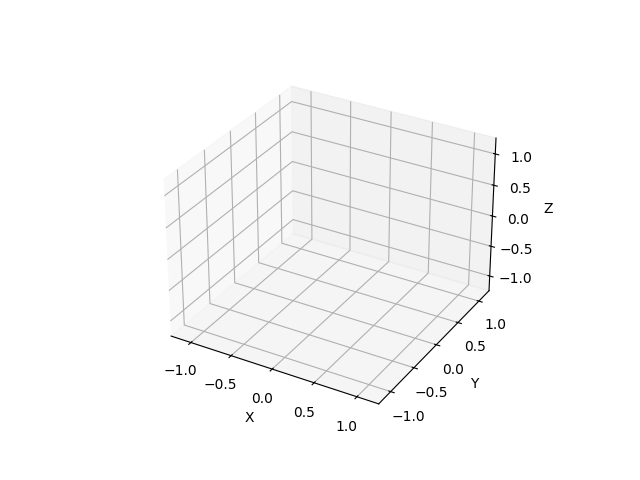

In [17]:
%matplotlib widget
plt.clf()
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.xlim(-1.25, 1.25)
plt.ylim(-1.25, 1.25)
ax.set_zlim(-1.25, 1.25)
def create_vec(unit_vector, color, mag):
    ax.quiver([0], [0], [0], [unit_vector[0] * mag], [unit_vector[1] * mag], [unit_vector[2] * mag], color = color)
def create_pt(unit_vector, color, thickness = 1):
    ax.scatter(unit_vector[0], unit_vector[1], unit_vector[2], c = color, s = thickness)
plt.show()

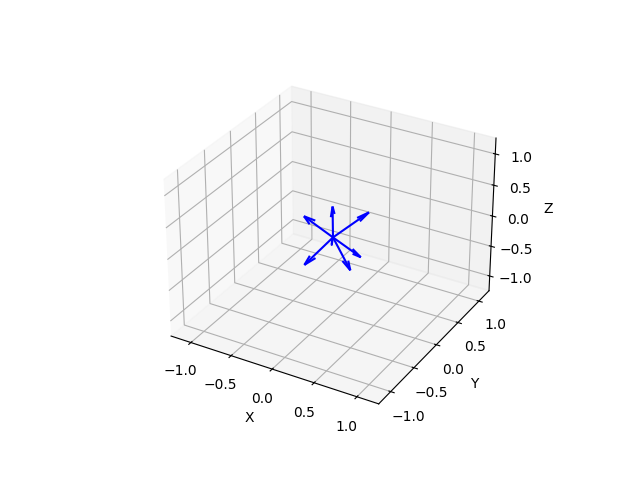

In [18]:
for pair in pairs:
    create_vec(pair.diode_1, 'b', 0.5)
    #create_vec(pair.diode_2, 'r', 0.5)
plt.show()

In [19]:
def run_sim_noisy(sun_phi, sun_theta, noise = 0.01):
    sols = []
    for pair in pairs:
        sols.append(pair.run_sim(sun_phi, sun_theta, noise))
    sols = list(filter(lambda x : x is not None, sols))
    if(len(sols) < 3):
        return None
    else:
        sols = np.array(sols)
        top_3 = sols[sols[:, 3].argsort()]
        coefficients = top_3[:, :3]
        results = top_3[:, 3]
        final = np.linalg.lstsq(coefficients, results)
        return final[0]
        

In [20]:
def run_noisy_tests(bound, d_o_n = 2, error_method = "magnitude", testing_degrees = 10): 
    #d_o_n = degrees of noise for noise generation
    noise = (1 - math.cos(math.radians(d_o_n)))
    errors = 0
    variation = 0
    nones = 0
    times = ((360/testing_degrees)**2)
    for phi in range(0, 360, testing_degrees):
        for theta in range(0, 360, testing_degrees):
            x = run_sim_noisy(phi, theta, noise)
            if x is not None:
                x = x / np.linalg.norm(x)
                sun_vector = np.array(spherical_to_xyz(phi, theta))
                if(error_method == "magnitude"):
                    error = np.linalg.norm(sun_vector - x)
                    variation += error
                    if(error < bound):
                        create_pt(spherical_to_xyz(phi, theta), 'g', 0.25)
                    else:
                        errors += 1
                        create_pt(spherical_to_xyz(phi, theta), 'r', 0.25)
                elif(error_method == "dot product"):
                    error = np.dot(sun_vector, x)
                    error = abs(math.degrees(math.acos(error)))
                    variation += error
                    if(error < bound):
                        create_pt(spherical_to_xyz(phi, theta), 'g', 0.25)
                    else:
                        errors += 1
                        create_pt(spherical_to_xyz(phi, theta), 'r', 0.25)
            else:
                create_pt(spherical_to_xyz(phi, theta), 'purple', 0.25)
                nones += 1
    return errors / times, variation / times, nones / times #error rate, average variation

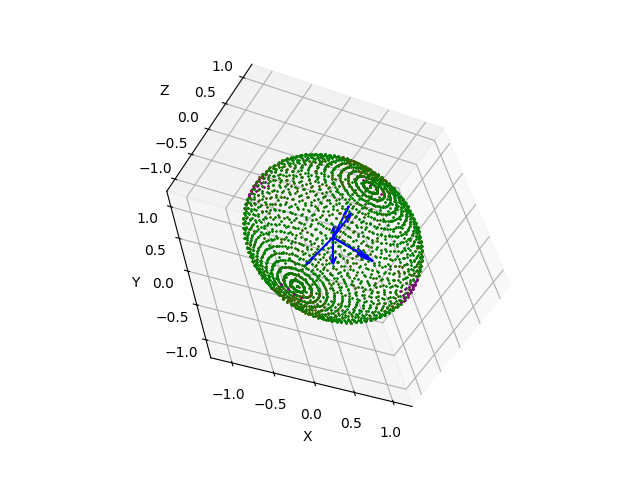

(0.0, 0.014168685606247794, 0.019290123456790122)


In [23]:

x = run_noisy_tests(d_o_n = , bound = 2, error_method = "dot product", testing_degrees = 5)
plt.show()
print(x)